In [35]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr
from qiskit.circuit import ControlFlowOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.transpiler.exceptions import TranspilerError
from qiskit.visualization import plot_circuit_layout
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Batch,
    SamplerV2 as Sampler,
)
import matplotlib.pyplot as plt
import numpy as np
import mthree


def configure_sampler_qem(sampler):
    """Set SamplerV2 error-suppression options (hardware applies; local Aer ignores)."""
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.enable_measure = True
    sampler.options.twirling.strategy = "active-accum"
    sampler.options.twirling.num_randomizations = "auto"
    sampler.options.twirling.shots_per_randomization = "auto"
    # DD is incompatible with dynamic circuits (mid-circuit measure / if_else).
    sampler.options.dynamical_decoupling.enable = False
    return sampler


## Fig. 5 / Appendix A.2 (Bäumer et al.)

논문 Fig. 2(c): mid-circuit measurement **`n/2 − 1`개**, CNOT **`3n/2 − 1`개**, 상수 2Q depth.

회로 순서 (n=7 예시와 동일, `dynamic_ghz(n)`으로 일반화):

1. `H` on even qubits `q0, q2, …`
2. V-CNOT: `cx(q_right, q_{right-1})` then `cx(q_left, q_{left+1})` (마지막 link 제외)
3. Mid-measure ancillas `q1, q3, …, q_{n-2}`
4. Prefix-XOR feed-forward: `X` on `q2, q4, …` if `m[0] ⊕ m[1] ⊕ …`
5. **`reset`** ancillas → `|0⟩`
6. Final even-pair CNOT: `(0,1), (2,3), …`

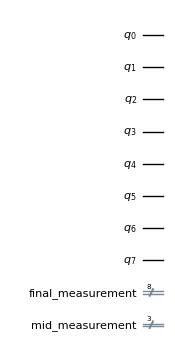

In [36]:
n_data = 8  # Number of data qubits in the GHZ chain (paper Fig. 5)


def mid_measurement_qubits(n_data):
    """Odd chain qubits measured mid-circuit (paper: n/2 - 1 measurements)."""
    return list(range(1, n_data - 1, 2))


def initialize_ghz_circuit(n_data):
    """Quantum/classical registers for dynamic GHZ (Fig. 5 / Appendix A.2)."""
    assert n_data >= 1
    q = QuantumRegister(n_data, "q")
    final_cr = ClassicalRegister(n_data, "final_measurement")
    qc = QuantumCircuit(q, final_cr, name="ghz_dynamic")
    mid_qubits = mid_measurement_qubits(n_data)
    if mid_qubits:
        qc.add_register(ClassicalRegister(len(mid_qubits), "mid_measurement"))
    return qc


qc = initialize_ghz_circuit(n_data)
qc.draw(fold=-1, output="mpl", scale=0.5)


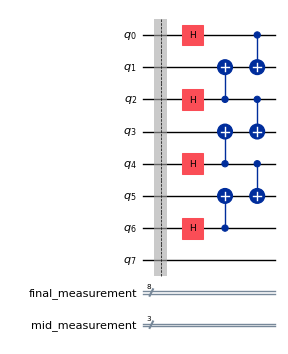

In [37]:
def apply_h_and_first_cx(qc, add_barrier=True):
    """Layer 1: H on even qubits + V-shaped CX (Fig. 5 / paper reference)."""
    n = qc.num_qubits
    if add_barrier:
        qc.barrier()
    qc.h(range(0, n, 2))
    for right in range(2, n, 2):
        qc.cx(right, right - 1)
    for left in range(0, n - 1, 2):
        if left + 1 < n - 1:  # defer cx(n-2, n-1) to final layer
            qc.cx(left, left + 1)
    return qc


qc = apply_h_and_first_cx(qc)
qc.draw(fold=-1, output="mpl", scale=0.5)


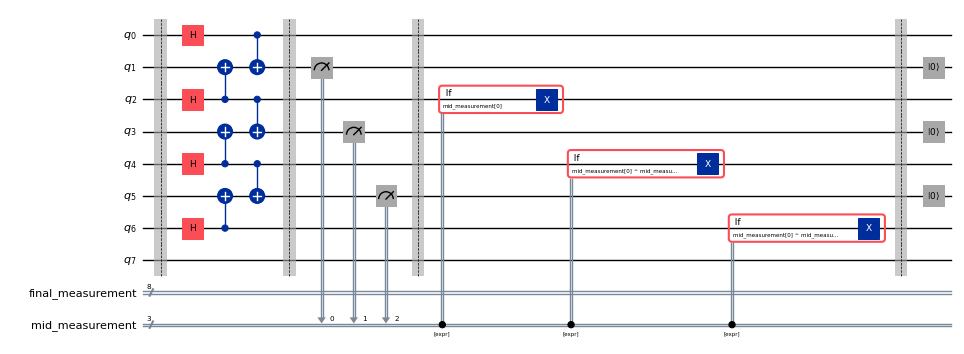

In [38]:
def apply_mid_measurements(qc, add_barrier=True):
    """Layer 2: mid-circuit measure, prefix-XOR feed-forward, ancilla reset.

    Ancillas q1, q3, ... q_{n-2} (n/2 - 1 measurements).
    Prefix parity of mid bits drives X on even qubits q2, q4, ... q_{n-2}.
    """
    n = qc.num_qubits
    mid = qc.cregs[-1]
    mid_qubits = mid_measurement_qubits(n)

    if not mid_qubits:
        return qc

    if add_barrier:
        qc.barrier()

    for clbit, qubit in zip(mid, mid_qubits):
        qc.measure(qubit, clbit)

    if add_barrier:
        qc.barrier()

    parity = expr.lift(mid[0])
    for bit, target in enumerate(range(2, n, 2)):
        if bit > 0:
            parity = expr.bit_xor(parity, mid[bit])
        with qc.if_test(parity):
            qc.x(target)

    if add_barrier:
        qc.barrier()

    for qubit in mid_qubits:
        qc.reset(qubit)
    return qc


qc = apply_mid_measurements(qc)
qc.draw(fold=-1, output="mpl", scale=0.5)


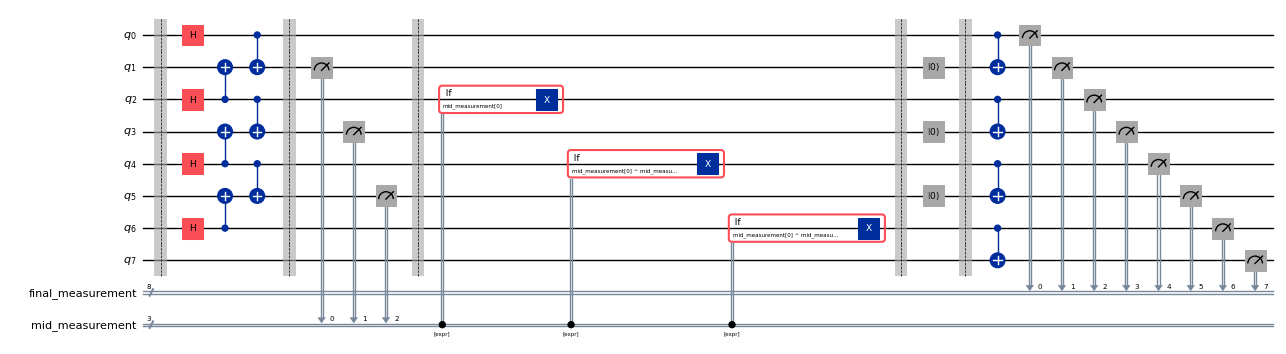

In [39]:
def apply_final_cx_and_measure(qc, do_measure=True, add_barrier=True):
    """Layer 3: even-neighbor CX (includes deferred cx(n-2,n-1)) + terminal measure."""
    n = qc.num_qubits
    if add_barrier:
        qc.barrier()
    for i in range(0, n - 1, 2):
        qc.cx(i, i + 1)
    if do_measure:
        qc.measure(qc.qubits, qc.cregs[0])
    return qc


qc = apply_final_cx_and_measure(qc)
qc.draw(fold=-1, output="mpl", scale=0.5)


In [40]:
from src.p1.ghz_circuit import dynamic_ghz_circuit, unitary_ghz_circuit

# Short aliases keep the remaining analysis cells readable.
dynamic_ghz = dynamic_ghz_circuit
unitary_ghz = unitary_ghz_circuit


qc = dynamic_ghz(n_data)
qc_uni = unitary_ghz(n_data)


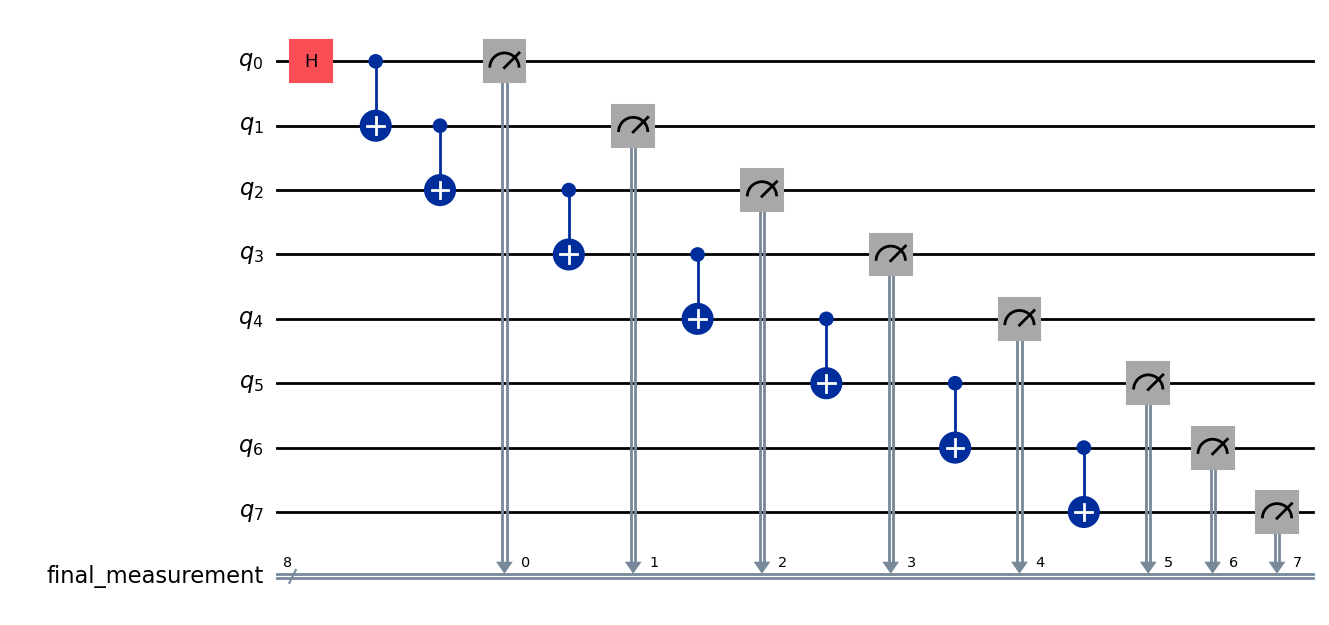

In [41]:
qc_uni.draw("mpl")

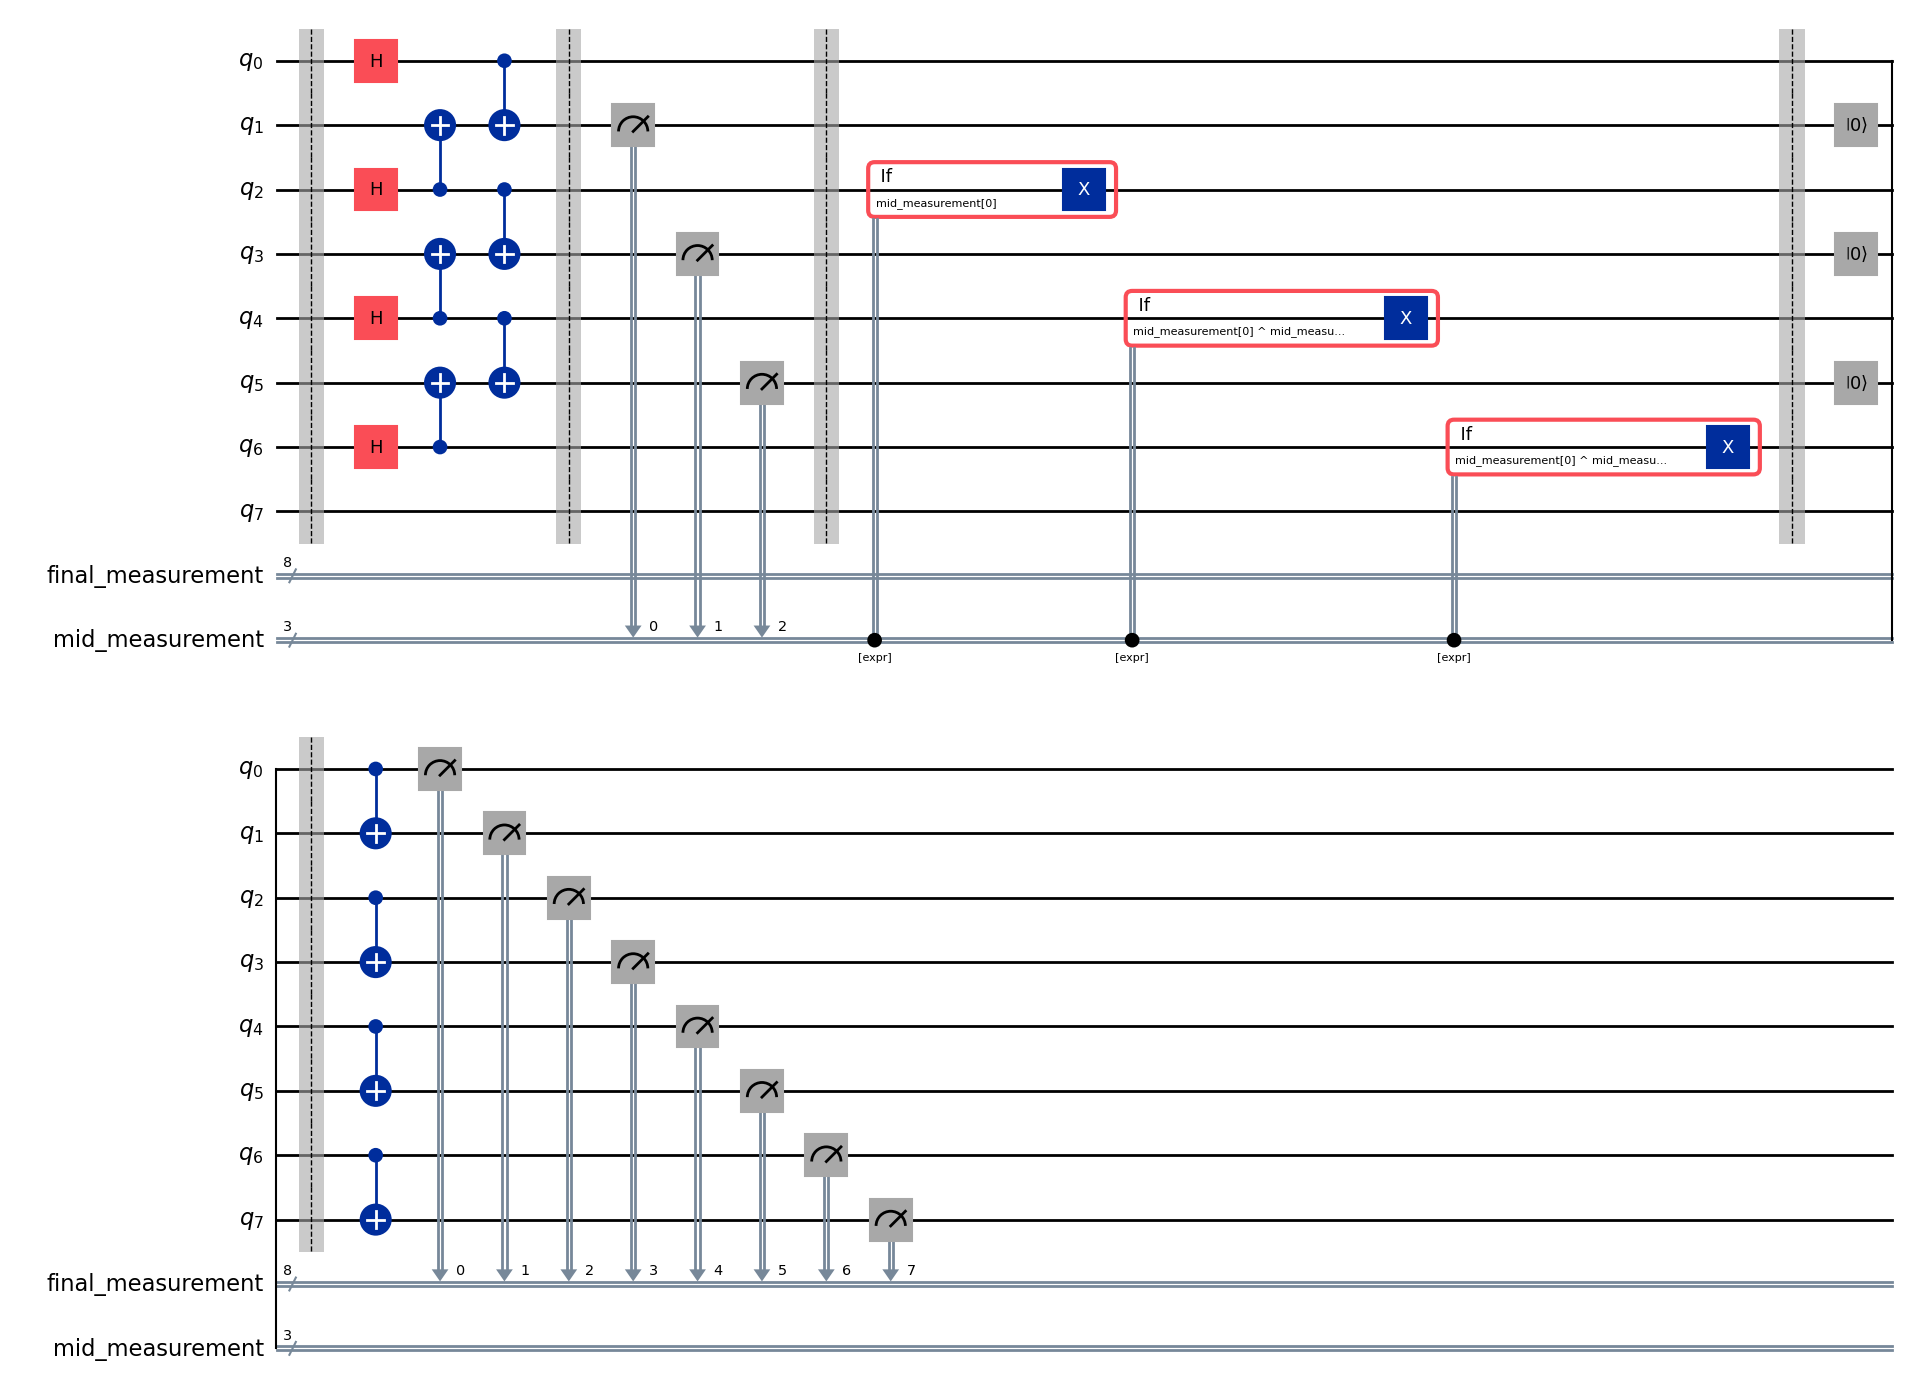

In [42]:
qc.draw("mpl")

In [43]:
# -------------------------Stabilizer sampling (paper Appendix C.1)-------------------------
_PAULI_MUL = {
    ("I", "I"): ("I", 1),
    ("I", "X"): ("X", 1),
    ("I", "Y"): ("Y", 1),
    ("I", "Z"): ("Z", 1),
    ("X", "I"): ("X", 1),
    ("X", "X"): ("I", 1),
    ("X", "Y"): ("Z", 1j),
    ("X", "Z"): ("Y", -1j),
    ("Y", "I"): ("Y", 1),
    ("Y", "X"): ("Z", -1j),
    ("Y", "Y"): ("I", 1),
    ("Y", "Z"): ("X", 1j),
    ("Z", "I"): ("Z", 1),
    ("Z", "X"): ("Y", 1j),
    ("Z", "Y"): ("X", -1j),
    ("Z", "Z"): ("I", 1),
}


def _pauli_product(pauli_a, pauli_b):
    out = []
    phase = 1
    for a, b in zip(pauli_a, pauli_b):
        p, f = _PAULI_MUL[(a, b)]
        out.append(p)
        if f in (1j, -1j):
            phase *= f
    if phase in (1j, -1j):
        raise ValueError("Y term with imaginary phase in stabilizer sample")
    return tuple(out), int(np.real(phase))


def ghz_stabilizer_generators(n):
    gens = [tuple("X" for _ in range(n))]
    for i in range(n - 1):
        p = ["I"] * n
        p[i] = "Z"
        p[i + 1] = "Z"
        gens.append(tuple(p))
    return gens


def random_ghz_stabilizer(n, rng):
    gens = ghz_stabilizer_generators(n)
    mask = rng.integers(0, 2, size=len(gens))
    if mask.sum() == 0:
        mask[0] = 1
    pauli = ["I"] * n
    sign = 1
    for use, gen in zip(mask, gens):
        if not use:
            continue
        pauli, phase = _pauli_product(pauli, list(gen))
        sign *= phase
    return sign, tuple(pauli)


def make_stabilizer_samples(n_data_values, m, seed=42):
    rng = np.random.default_rng(seed)
    return {n: [random_ghz_stabilizer(n, rng) for _ in range(m)] for n in n_data_values}


def append_stabilizer_measurement(qc, pauli):
    n = qc.num_qubits
    cr = ClassicalRegister(n, "stabilizer")
    qc.add_register(cr)
    for i, p in enumerate(pauli):
        if p == "X":
            qc.h(i)
        elif p == "Y":
            qc.sdg(i)
            qc.h(i)
    qc.barrier()
    qc.measure(range(n), cr)
    return qc


def ghz_stabilizer_circuit(prep_fn, n, sign, pauli):
    qc = prep_fn(n)
    append_stabilizer_measurement(qc, pauli)
    return qc


def stabilizer_expectation(counts, pauli, sign, n):
    total = sum(counts.values())
    if total == 0:
        return 0.0
    exp = 0.0
    for bitstring, freq in counts.items():
        bits = bitstring.replace(" ", "")[-n:]
        parity = 1
        for i, p in enumerate(pauli):
            if p == "I":
                continue
            parity *= (-1) ** int(bits[-(i + 1)])
        exp += sign * parity * freq
    return exp / total


def stabilizer_expectation_quasi(quasis, pauli, sign, n):
    total = sum(quasis.values())
    if total == 0:
        return 0.0
    exp = 0.0
    for bitstring, weight in quasis.items():
        bits = bitstring.replace(" ", "")[-n:]
        parity = 1
        for i, p in enumerate(pauli):
            if p == "I":
                continue
            parity *= (-1) ** int(bits[-(i + 1)])
        exp += sign * parity * weight
    return exp / total


def mc_ghz_fidelity(expectations):
    return float(np.mean(expectations))


In [44]:
# Ideal simulator sanity check
from qiskit_aer import AerSimulator

aer_backend = AerSimulator()
pm_sim = generate_preset_pass_manager(optimization_level=0, backend=aer_backend)
isa_dyn = pm_sim.run(dynamic_ghz(n_data))
isa_uni = pm_sim.run(unitary_ghz(n_data))

sampler_sim = configure_sampler_qem(Sampler(mode=aer_backend))
sim_results = sampler_sim.run([isa_dyn, isa_uni]).result()


def get_final_counts(pub_result):
    return pub_result.data.final_measurement.get_counts()


def ghz_success_rate(counts, n_data):
    total = sum(counts.values())
    if total == 0:
        return 0.0
    targets = {"0" * n_data, "1" * n_data}
    ok = sum(
        freq
        for bitstring, freq in counts.items()
        if bitstring.replace(" ", "")[-n_data:] in targets
    )
    return ok / total


counts_dyn = get_final_counts(sim_results[0])
counts_uni = get_final_counts(sim_results[1])
print(f"Dynamic GHZ success (n={n_data}): {100 * ghz_success_rate(counts_dyn, n_data):.1f}%")
print(f"Unitary GHZ success (n={n_data}): {100 * ghz_success_rate(counts_uni, n_data):.1f}%")

# Stabilizer fidelity (all generators — noiseless should be 1.0)
gen_expectations_dyn = [
    stabilizer_expectation(
        sampler_sim.run(
            [pm_sim.run(ghz_stabilizer_circuit(lambda n: dynamic_ghz(n, do_measure=False), n_data, s, p))]
        )
        .result()[0]
        .data.stabilizer.get_counts(),
        p,
        s,
        n_data,
    )
    for s, p in [(1, g) for g in ghz_stabilizer_generators(n_data)]
]
gen_expectations_uni = [
    stabilizer_expectation(
        sampler_sim.run(
            [pm_sim.run(ghz_stabilizer_circuit(lambda n: unitary_ghz(n, do_measure=False), n_data, s, p))]
        )
        .result()[0]
        .data.stabilizer.get_counts(),
        p,
        s,
        n_data,
    )
    for s, p in [(1, g) for g in ghz_stabilizer_generators(n_data)]
]
print(f"Dynamic stabilizer fidelity (n={n_data}, all generators): {mc_ghz_fidelity(gen_expectations_dyn):.4f}")
print(f"Unitary stabilizer fidelity (n={n_data}, all generators): {mc_ghz_fidelity(gen_expectations_uni):.4f}")


Dynamic GHZ success (n=8): 100.0%
Unitary GHZ success (n=8): 100.0%
Dynamic stabilizer fidelity (n=8, all generators): 1.0000
Unitary stabilizer fidelity (n=8, all generators): 1.0000


# Scaling


## QEM: 두 가지 레이어

### 1) Qiskit Runtime (SamplerV2) — 실행 시 옵션
모든 `Sampler`에 `configure_sampler_qem()` 적용.

### 2) M3 readout mitigation (Step 3b)
[CNOT notebook과 동일](https://quantum.cloud.ibm.com/docs/en/tutorials/readout-error-mitigation-sampler) M3 protocol.
`USE_REAL_HARDWARE=False`(기본)이면 Step 2b/3 모두 **로컬 noisy Aer** — IBM queue job 없음.


In [45]:
# -------------------------QEM config-------------------------
# Requires: pip install mthree
APPLY_READOUT_MITIGATION = True
USE_REAL_HARDWARE = False
NUM_STABILIZER_SAMPLES = 12  # m random stabilizers per n (Problem 1)


In [46]:
# -------------------------Step 1-------------------------
n_data_values = [4, 6, 8, 10]
n_data_values.sort()
assert min(n_data_values) >= 2

stabilizer_samples = make_stabilizer_samples(n_data_values, NUM_STABILIZER_SAMPLES)

# Prep + terminal measurement (resource metrics)
circuits_dyn_prep = [dynamic_ghz(n) for n in n_data_values]
circuits_uni_prep = [unitary_ghz(n) for n in n_data_values]

# Stabilizer certification circuits
circuits_dyn = []
circuits_uni = []
for n in n_data_values:
    for sign, pauli in stabilizer_samples[n]:
        circuits_dyn.append(
            ghz_stabilizer_circuit(lambda n, fn=dynamic_ghz: fn(n, do_measure=False), n, sign, pauli)
        )
        circuits_uni.append(
            ghz_stabilizer_circuit(lambda n, fn=unitary_ghz: fn(n, do_measure=False), n, sign, pauli)
        )

print(f"Dynamic stabilizer circuits: {len(circuits_dyn)}")
print(f"Unitary stabilizer circuits: {len(circuits_uni)}")
print(f"Samples per n: {NUM_STABILIZER_SAMPLES}")


Dynamic stabilizer circuits: 48
Unitary stabilizer circuits: 48
Samples per n: 12


In [53]:
# -------------------------Step 2-------------------------
from qiskit.circuit import IfElseOp
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez

service = QiskitRuntimeService(name="YONSEI-SKQD")
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend_sim = AerSimulator().from_backend(backend)
print(backend_sim)


AerSimulator('aer_simulator_from(ibm_yonsei)'
             noise_model=<NoiseModel on ['x', 'reset', 'measure', 'sx', 'ecr', 'id']>)


In [54]:
execution_backend = backend if USE_REAL_HARDWARE else backend_sim
print(f"Execution backend: {execution_backend} (USE_REAL_HARDWARE={USE_REAL_HARDWARE})")


Execution backend: AerSimulator('aer_simulator_from(ibm_yonsei)'
             noise_model=<NoiseModel on ['x', 'reset', 'measure', 'sx', 'ecr', 'id']>) (USE_REAL_HARDWARE=False)


In [55]:
if "if_else" not in backend.target.operation_names:
    backend.target.add_instruction(IfElseOp, name="if_else")


In [56]:
lf_qubits = backend.properties().to_dict()["general_qlists"]
max_n = max(n_data_values)
chain = [val["qubits"] for val in lf_qubits if val["name"] == f"lf_{max_n}"][0]
chosen_layouts = {n: chain[:n] for n in n_data_values}
print(f"Longest chain ({max_n} qubits):", chosen_layouts[max_n])


Longest chain (10 qubits): [118, 119, 120, 121, 122, 111, 104, 103, 102, 101]


In [57]:
isa_circuits_dyn = []
isa_circuits_uni = []
isa_circuits_dyn_prep = []
isa_circuits_uni_prep = []

for qc in circuits_dyn:
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=backend,
        initial_layout=chosen_layouts[qc.num_qubits],
    )
    isa_circuits_dyn.append(pm.run(qc))

for qc in circuits_uni:
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=backend,
        initial_layout=chosen_layouts[qc.num_qubits],
    )
    isa_circuits_uni.append(pm.run(qc))

for qc in circuits_dyn_prep:
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=backend,
        initial_layout=chosen_layouts[qc.num_qubits],
    )
    isa_circuits_dyn_prep.append(pm.run(qc))

for qc in circuits_uni_prep:
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=backend,
        initial_layout=chosen_layouts[qc.num_qubits],
    )
    isa_circuits_uni_prep.append(pm.run(qc))


2Q depth dynamic (n=8): 3


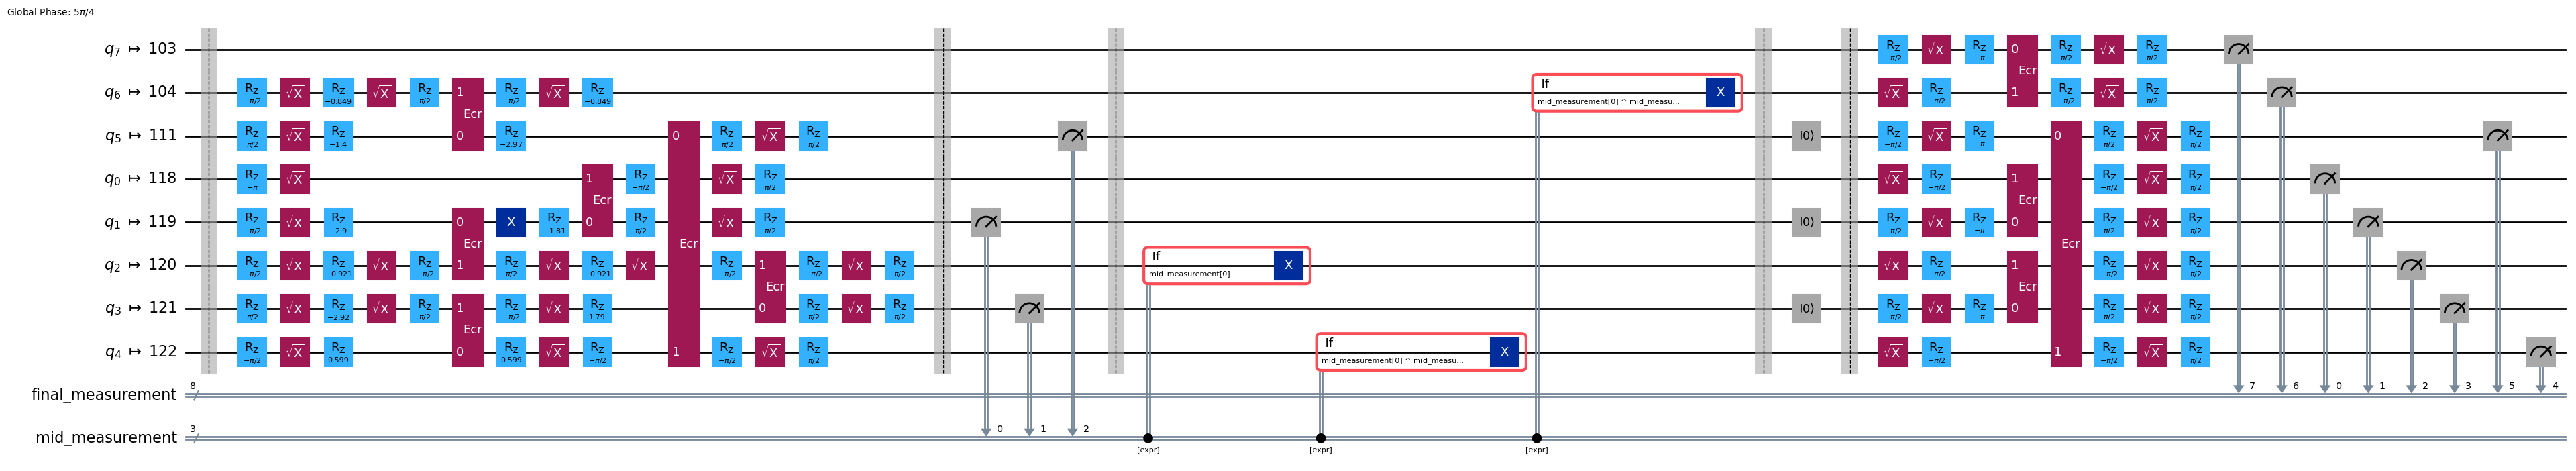

In [58]:
mid = len(n_data_values) // 2
print(
    f"2Q depth dynamic (n={n_data_values[mid]}): "
    f"{isa_circuits_dyn_prep[mid].depth(lambda x: x.operation.num_qubits == 2)}"
)
isa_circuits_dyn_prep[mid].draw("mpl", fold=-1, idle_wires=False)


2Q depth unitary (n=8): 7


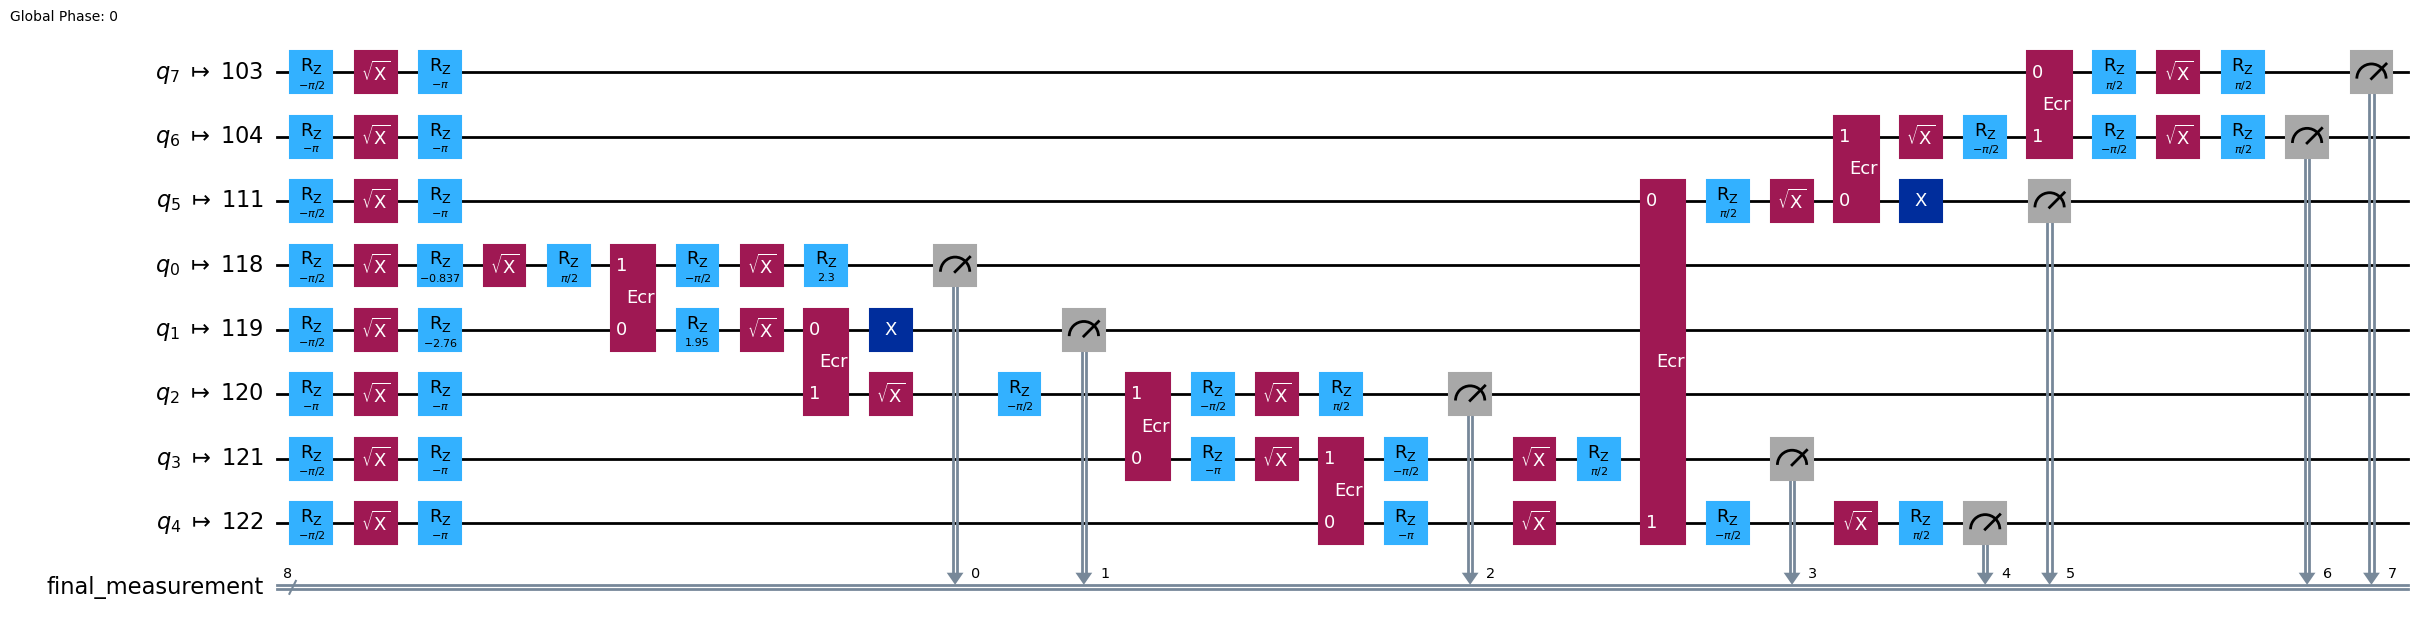

In [59]:
print(
    f"2Q depth unitary (n={n_data_values[mid]}): "
    f"{isa_circuits_uni_prep[mid].depth(lambda x: x.operation.num_qubits == 2)}"
)
isa_circuits_uni_prep[mid].draw("mpl", fold=-1, idle_wires=False)


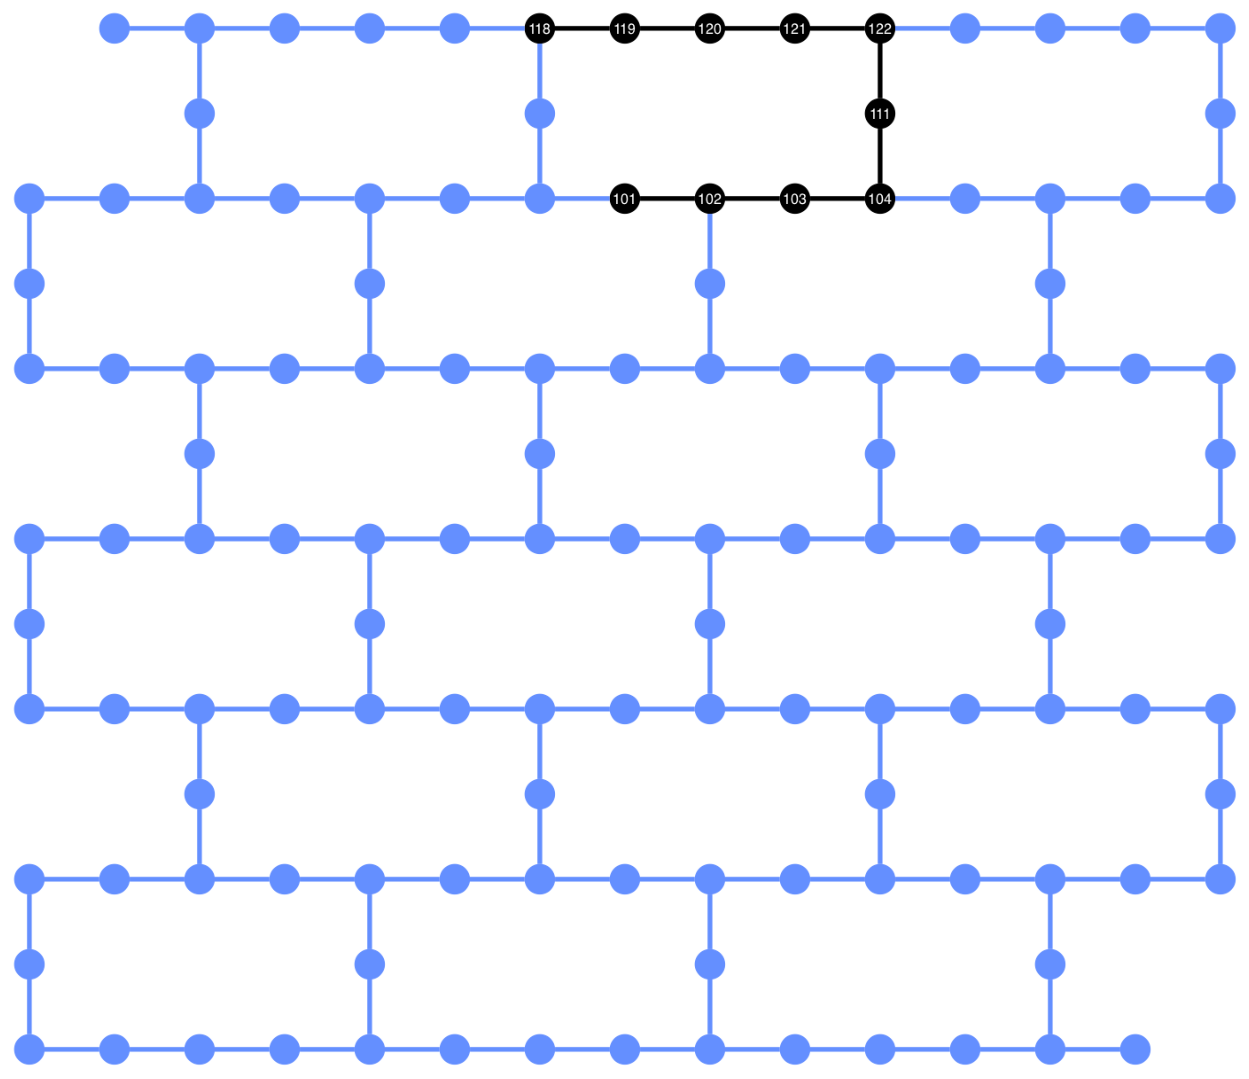

In [60]:
plot_circuit_layout(
    circuit=isa_circuits_uni_prep[-1],
    backend=backend,
    view="physical",
    qubit_coordinates=None,
)


In [61]:
# -------------------------Step 2b: M3 calibration-------------------------
ALL_BENCHMARK_QUBITS = sorted({q for layout in chosen_layouts.values() for q in layout})

m3_mit = mthree.M3Mitigation(execution_backend)
m3_cal_method = "balanced" if USE_REAL_HARDWARE else "independent"
m3_mit.cals_from_system(
    ALL_BENCHMARK_QUBITS,
    method=m3_cal_method,
    rep_delay=None,
)
print(
    f"M3 calibrated on {len(ALL_BENCHMARK_QUBITS)} qubits "
    f"via {execution_backend} (method={m3_cal_method})"
)


M3 calibrated on 10 qubits via AerSimulator('aer_simulator_from(ibm_yonsei)'
             noise_model=<NoiseModel on ['x', 'reset', 'measure', 'sx', 'ecr', 'id']>) (method=independent)


In [62]:
# -------------------------QEM helpers-------------------------

def get_stabilizer_counts(pub_result):
    return pub_result.data.stabilizer.get_counts()


def _circuit_index(n_index, sample_index):
    return n_index * NUM_STABILIZER_SAMPLES + sample_index


def mc_fidelity_from_job(result, n_index, n, layout=None, mit=None):
    expectations = []
    for s_idx, (sign, pauli) in enumerate(stabilizer_samples[n]):
        counts = get_stabilizer_counts(result[_circuit_index(n_index, s_idx)])
        if mit is not None and layout is not None:
            quasis = mit.apply_correction(counts, layout)
            expectations.append(stabilizer_expectation_quasi(quasis, pauli, sign, n))
        else:
            expectations.append(stabilizer_expectation(counts, pauli, sign, n))
    return mc_ghz_fidelity(expectations)


def aggregate_fidelities(jobs, n_data_values):
    trials = []
    for job in jobs:
        result = job.result()
        trial = [
            mc_fidelity_from_job(result, ind, n)
            for ind, n in enumerate(n_data_values)
        ]
        trials.append(trial)
    arr = np.array(trials)
    return arr.mean(axis=0), arr.std(axis=0)


def aggregate_fidelities_with_m3(jobs, n_data_values, chosen_layouts, mit):
    trials = []
    for job in jobs:
        result = job.result()
        trial = [
            mc_fidelity_from_job(result, ind, n, chosen_layouts[n], mit)
            for ind, n in enumerate(n_data_values)
        ]
        trials.append(trial)
    arr = np.array(trials)
    return arr.mean(axis=0), arr.std(axis=0)


In [63]:
# -------------------------Step 3: baseline-------------------------
num_trials = 10
jobs_dyn = []
jobs_uni = []
with Batch(backend=execution_backend) as batch:
    sampler = configure_sampler_qem(Sampler(mode=batch))
    sampler.options.environment.job_tags = ["TUT_GHZ"]
    print("Sampler QEM options:", sampler.options.twirling, sampler.options.dynamical_decoupling)
    for _ in range(num_trials):
        jobs_dyn.append(sampler.run(isa_circuits_dyn, shots=1024))
        jobs_uni.append(sampler.run(isa_circuits_uni, shots=1024))


Sampler QEM options: TwirlingOptions(enable_gates=True, enable_measure=True, num_randomizations='auto', shots_per_randomization='auto', strategy='active-accum') DynamicalDecouplingOptions(enable=False, sequence_type=Unset, extra_slack_distribution=Unset, scheduling_method=Unset, skip_reset_qubits=Unset)


/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': True, 'enable_measure': True, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'strategy': 'active-accum'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [64]:
# -------------------------Step 3b: QEM (M3 readout mitigation)-------------------------
avg_fidelities_dyn_qem = std_fidelities_dyn_qem = None
avg_fidelities_uni_qem = std_fidelities_uni_qem = None

if APPLY_READOUT_MITIGATION:
    avg_fidelities_dyn_qem, std_fidelities_dyn_qem = aggregate_fidelities_with_m3(
        jobs_dyn, n_data_values, chosen_layouts, m3_mit
    )
    avg_fidelities_uni_qem, std_fidelities_uni_qem = aggregate_fidelities_with_m3(
        jobs_uni, n_data_values, chosen_layouts, m3_mit
    )
    raw_dyn, _ = aggregate_fidelities(jobs_dyn, n_data_values)
    print("M3 readout mitigation (Dynamic):")
    for n, raw, mit in zip(n_data_values, raw_dyn, avg_fidelities_dyn_qem):
        print(f"  n={n:2d}: {raw:.3f} -> {mit:.3f}  (+{mit - raw:.3f})")
else:
    print("APPLY_READOUT_MITIGATION=False")


M3 readout mitigation (Dynamic):
  n= 4: 0.571 -> 0.903  (+0.332)
  n= 6: 0.326 -> 0.691  (+0.364)
  n= 8: 0.272 -> 0.641  (+0.369)
  n=10: 0.198 -> 0.457  (+0.259)


In [65]:
# -------------------------Step 4-------------------------
avg_fidelities_dyn, std_fidelities_dyn = aggregate_fidelities(jobs_dyn, n_data_values)
avg_fidelities_uni, std_fidelities_uni = aggregate_fidelities(jobs_uni, n_data_values)


In [66]:
# -------------------------Circuit resource metrics-------------------------
from collections import defaultdict

_TWO_QUBIT_FILTER = lambda inst: inst.operation.num_qubits == 2


def _two_qubit_depth(qc):
    return qc.depth(_TWO_QUBIT_FILTER)


def _count_two_qubit_gates(qc):
    return sum(1 for inst in qc.data if inst.operation.num_qubits == 2)


def _count_cnot_ecr(qc):
    return sum(1 for inst in qc.data if inst.operation.name in {"cx", "ecr"})


def _count_measurements(qc):
    return sum(1 for inst in qc.data if inst.operation.name == "measure")


def _count_mid_circuit_measurements(qc):
    return max(0, _count_measurements(qc) - qc.num_qubits)


def _idle_time_by_qubit_dt(qc):
    idle = defaultdict(int)
    for inst in qc.data:
        if inst.operation.name != "delay":
            continue
        duration = int(inst.operation.params[0])
        for qubit in inst.qubits:
            idle[qubit] += duration
    return dict(idle)


def _has_control_flow(qc):
    for inst in qc.data:
        if isinstance(inst.operation, ControlFlowOp):
            return True
    return False


def _duration_us(qc, backend):
    duration_dt = getattr(qc, "duration", None)
    if duration_dt is None:
        return None
    return duration_dt * backend.dt * 1e6


def _backend_timing_us(backend):
    timing = {"feedforward_us": 0.7, "measure_us": 1.2, "two_q_us": 0.5}
    try:
        timing["two_q_us"] = float(backend.properties().gate_length("cx", [0, 1])) * 1e6
    except Exception:
        pass
    return timing


def _estimate_dynamic_timing(qc, backend):
    timing = _backend_timing_us(backend)
    n_mid = _count_mid_circuit_measurements(qc)
    depth_2q = _two_qubit_depth(qc)
    ff, meas, two_q = timing["feedforward_us"], timing["measure_us"], timing["two_q_us"]
    idle_us = n_mid * (meas + ff)
    duration_us = depth_2q * two_q + n_mid * (meas + ff) + qc.num_qubits * meas
    return idle_us, duration_us, meas + ff


def _schedule_isa(qc, backend):
    if _has_control_flow(qc):
        return None
    pm = generate_preset_pass_manager(
        optimization_level=0,
        backend=backend,
        scheduling_method="alap",
    )
    try:
        return pm.run(qc)
    except TranspilerError:
        return None


def circuit_metrics(qc, backend, schedule=True):
    metrics = {
        "two_qubit_depth": _two_qubit_depth(qc),
        "two_qubit_count": _count_two_qubit_gates(qc),
        "cnot_ecr_count": _count_cnot_ecr(qc),
        "mid_circuit_measurements": _count_mid_circuit_measurements(qc),
        "measure_total": _count_measurements(qc),
        "idle_time_us": None,
        "timing_source": None,
    }
    if schedule:
        sched = _schedule_isa(qc, backend)
        if sched is not None:
            idle_dt = sum(_idle_time_by_qubit_dt(sched).values())
            metrics["idle_time_us"] = idle_dt * backend.dt * 1e6
            metrics["timing_source"] = "alap"
        else:
            idle_us, _, _ = _estimate_dynamic_timing(qc, backend)
            metrics["idle_time_us"] = idle_us
            metrics["timing_source"] = "estimated (control flow)"
    return metrics


def metrics_table(isa_circuits, label):
    rows = []
    for n_index, n in enumerate(n_data_values):
        m = circuit_metrics(isa_circuits[n_index], backend, schedule=True)
        rows.append({"n_data": n, "variant": label, **m})
    return rows


metrics_dyn = metrics_table(isa_circuits_dyn_prep, "dynamic")
metrics_uni = metrics_table(isa_circuits_uni_prep, "unitary")

header = (
    f"{'n':>4} {'variant':>8} {'2Q depth':>8} {'2Q cnt':>7} "
    f"{'CNOT/ECR':>8} {'MC meas':>7} {'meas':>5} {'idle us':>10} {'timing':>12}"
)
print(header)
print("-" * len(header))
for row in metrics_dyn + metrics_uni:
    timing = row.get("timing_source") or "n/a"
    idle = row["idle_time_us"]
    idle_str = f"{idle:10.2f}" if idle is not None else f"{'n/a':>10}"
    print(
        f"{row['n_data']:4d} {row['variant']:>8} "
        f"{row['two_qubit_depth']:8d} {row['two_qubit_count']:7d} "
        f"{row['cnot_ecr_count']:8d} {row['mid_circuit_measurements']:7d} "
        f"{row['measure_total']:5d} {idle_str} {timing:>12}"
    )


   n  variant 2Q depth  2Q cnt CNOT/ECR MC meas  meas    idle us       timing
-----------------------------------------------------------------------------
   4  dynamic        3       4        4       0     5       0.00 estimated (control flow)
   6  dynamic        3       7        7       0     8       0.00 estimated (control flow)
   8  dynamic        3      10       10       0    11       0.00 estimated (control flow)
  10  dynamic        3      13       13       0    14       0.00 estimated (control flow)
   4  unitary        3       3        3       0     4     485.04         alap
   6  unitary        5       5        5       0     6     655.52         alap
   8  unitary        7       7        7       0     8     826.00         alap
  10  unitary        9       9        9       0    10     996.48         alap


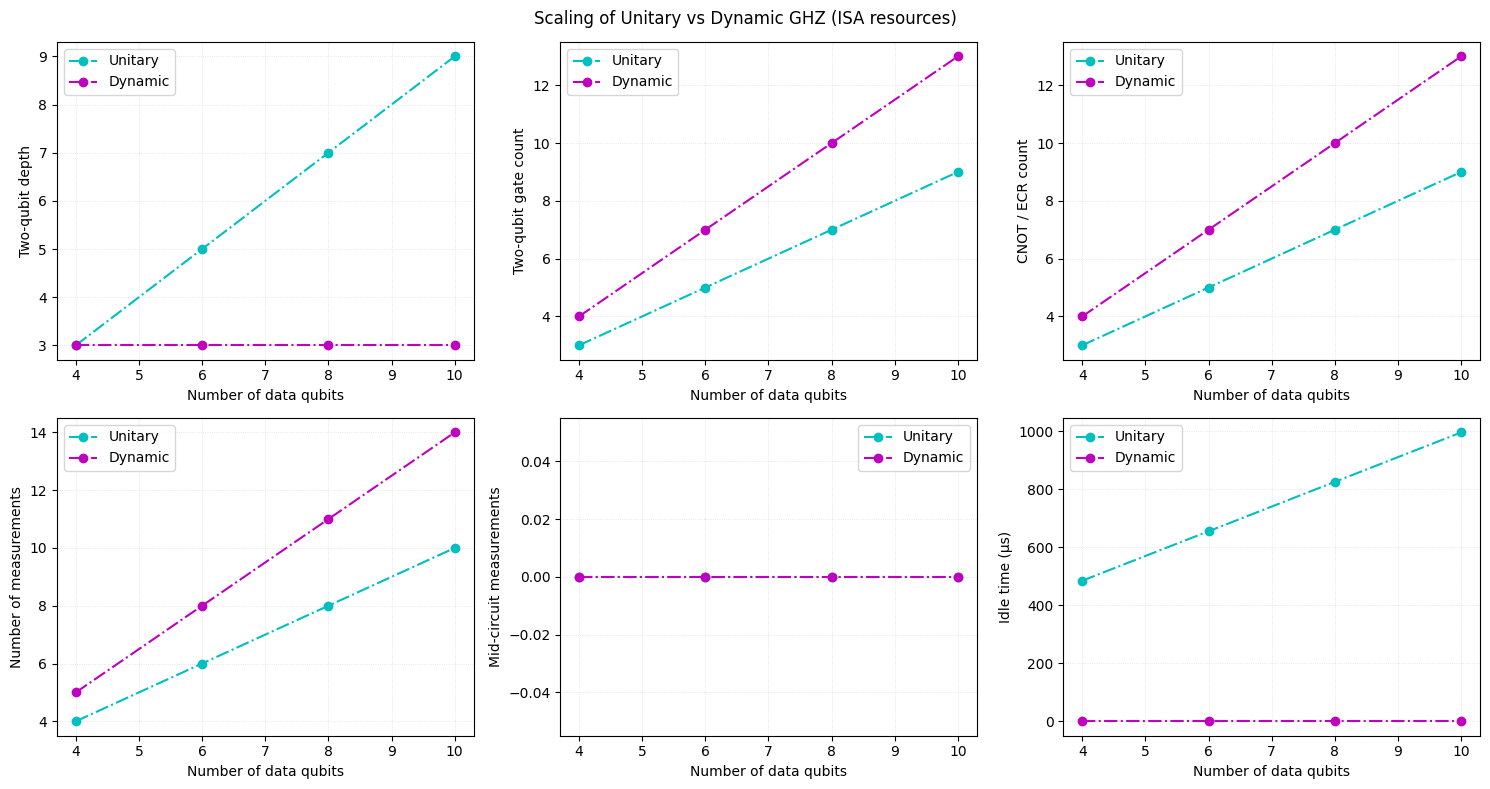

In [70]:
# Resource scaling plots (CNOT notebook style)
_xlabel = "Number of data qubits"


def _plot_uni_dyn(ax, uni_y, dyn_y, ylabel, uni_label="Unitary", dyn_label="Dynamic"):
    ax.plot(n_data_values, uni_y, "o-.", color="c", label=uni_label)
    ax.plot(n_data_values, dyn_y, "o-.", color="m", label=dyn_label)
    ax.set_xlabel(_xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.4)
    ax.legend()


_metric_panels = [
    (
        [r["two_qubit_depth"] for r in metrics_uni],
        [r["two_qubit_depth"] for r in metrics_dyn],
        "Two-qubit depth",
    ),
    (
        [r["two_qubit_count"] for r in metrics_uni],
        [r["two_qubit_count"] for r in metrics_dyn],
        "Two-qubit gate count",
    ),
    (
        [r["cnot_ecr_count"] for r in metrics_uni],
        [r["cnot_ecr_count"] for r in metrics_dyn],
        "CNOT / ECR count",
    ),
    (
        [r["measure_total"] for r in metrics_uni],
        [r["measure_total"] for r in metrics_dyn],
        "Number of measurements",
    ),
    (
        [0] * len(n_data_values),
        [r["mid_circuit_measurements"] for r in metrics_dyn],
        "Mid-circuit measurements",
    ),
    (
        [r["idle_time_us"] for r in metrics_uni],
        [r["idle_time_us"] for r in metrics_dyn],
        "Idle time (µs)",
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (uni_y, dyn_y, ylabel) in zip(axes.ravel(), _metric_panels):
    _plot_uni_dyn(ax, uni_y, dyn_y, ylabel)

fig.suptitle("Scaling of Unitary vs Dynamic GHZ (ISA resources)", fontsize=12)
plt.tight_layout()
plt.show()


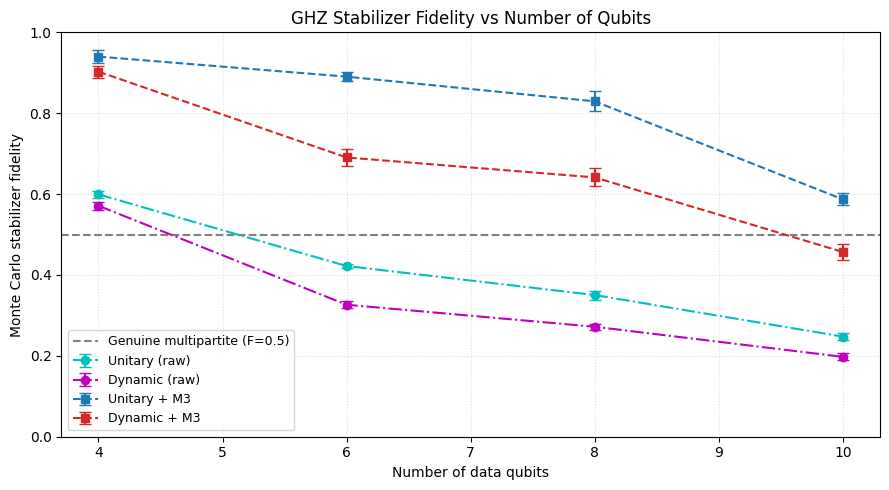

In [71]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    n_data_values, avg_fidelities_uni, yerr=std_fidelities_uni,
    fmt="o-.", color="c", capsize=4, label="Unitary (raw)",
)
ax.errorbar(
    n_data_values, avg_fidelities_dyn, yerr=std_fidelities_dyn,
    fmt="o-.", color="m", capsize=4, label="Dynamic (raw)",
)

if avg_fidelities_dyn_qem is not None:
    ax.errorbar(
        n_data_values, avg_fidelities_uni_qem, yerr=std_fidelities_uni_qem,
        fmt="s--", color="tab:blue", capsize=4, label="Unitary + M3",
    )
    ax.errorbar(
        n_data_values, avg_fidelities_dyn_qem, yerr=std_fidelities_dyn_qem,
        fmt="s--", color="tab:red", capsize=4, label="Dynamic + M3",
    )

ax.axhline(y=0.5, linestyle="--", color="gray", label="Genuine multipartite (F=0.5)")
ax.set_title("GHZ Stabilizer Fidelity vs Number of Qubits")
ax.set_xlabel("Number of data qubits")
ax.set_ylabel("Monte Carlo stabilizer fidelity")
ax.set_ylim(0.0, 1.0)
ax.grid(linestyle=":", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [69]:
example_n = 8
example_idx = n_data_values.index(example_n)
print(f"Example n={example_n}")
for label, isa_list in [("dynamic", isa_circuits_dyn_prep), ("unitary", isa_circuits_uni_prep)]:
    m = circuit_metrics(isa_list[example_idx], backend, schedule=False)
    print(
        f"  {label:8s}: 2Q depth={m['two_qubit_depth']}, "
        f"2Q count={m['two_qubit_count']}, CNOT/ECR={m['cnot_ecr_count']}, "
        f"mid-circuit meas={m['mid_circuit_measurements']}"
    )

isa_circuits_dyn_prep[example_idx].draw("mpl", fold=-1, idle_wires=False)
plt.show()
isa_circuits_uni_prep[example_idx].draw("mpl", fold=-1, idle_wires=False)
plt.show()


Example n=8
  dynamic : 2Q depth=3, 2Q count=10, CNOT/ECR=10, mid-circuit meas=0
  unitary : 2Q depth=7, 2Q count=7, CNOT/ECR=7, mid-circuit meas=0
